# 📘 Session 11: Data Visualization with Matplotlib and Seaborn
### Duration: ~2 Hours

---

**Topics Covered:**
1. Introduction to Data Visualization
2. Matplotlib Fundamentals
3. Common Plot Types with Matplotlib
4. Advanced Matplotlib (Subplots, Customization & Saving)
5. Introduction to Seaborn

---

**Why This Session Matters for Data Science:**
- **Data visualization** is how you communicate insights to stakeholders
- **Exploratory data analysis (EDA)** relies on visual patterns and outliers
- **Model evaluation** uses plots to assess performance and errors
- **Storytelling with data** requires clear, compelling visualizations
- **Decision making** is faster and more confident with visual evidence

> Data visualization transforms numbers into narratives. This session focuses on Matplotlib's core capabilities while introducing Seaborn basics.

---
## 1. Introduction to Data Visualization

Data visualization is the bridge between data analysis and decision making. Choose the right plot for your data and audience.

### Visualization Libraries Comparison

| Library | Best For | Learning Curve | Customization | Use Case |
|---------|----------|----------------|---------------|----------|
| **Matplotlib** | Full control, publication-quality | Steep | Very high | Scientific plots, custom layouts |
| **Seaborn** | Statistical plots, beautiful defaults | Medium | Medium | EDA, statistical visualization |
| **Plotly** | Interactive web plots | Medium | High | Dashboards, web applications |
| **ggplot2** | Layered grammar of graphics | Medium | High | Statistical analysis |

### Choosing the Right Plot Type

| Data Type | Best Plot Types | Purpose |
|-----------|-----------------|---------|
| **Numerical vs Numerical** | Scatter plot, line plot | Show relationships, trends |
| **Categorical vs Numerical** | Bar chart, box plot, violin plot | Compare groups, distributions |
| **Time Series** | Line plot, area plot | Show trends over time |
| **Distribution** | Histogram, density plot, box plot | Show data spread and outliers |
| **Composition** | Pie chart, stacked bar | Show parts of a whole |
| **Correlation** | Heatmap, scatter matrix | Show relationships between variables |

> ⚠️ **Special Case — Pie charts**: Only use for composition data with few categories (≤5). Bar charts are almost always better.

> **Data Science relevance**: 80% of data science insights come from visualization. The right plot can reveal patterns invisible in tables.

In [21]:
# --- Setting up visualization environment ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for consistent plotting
plt.style.use('default')  # or 'seaborn', 'ggplot', etc.

# Enable inline plotting in Jupyter
%matplotlib inline

# Create sample dataset
np.random.seed(42)
sales_data = pd.DataFrame({
    'Month': pd.date_range('2024-01-01', periods=12, freq='ME'),
    'Sales': np.random.normal(1000, 200, 12),
    'Profit': np.random.normal(200, 50, 12),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 12),
    'Product': np.random.choice(['A', 'B', 'C'], 12)
})

print('Sample sales data:')
print(sales_data.head())
print(f"\nData shape: {sales_data.shape}")
print(f"Columns: {list(sales_data.columns)}")

Sample sales data:
       Month        Sales      Profit Region Product
0 2024-01-31  1099.342831  212.098114   West       B
1 2024-02-29   972.347140  104.335988  North       B
2 2024-03-31  1129.537708  113.754108   East       B
3 2024-04-30  1304.605971  171.885624  North       A
4 2024-05-31   953.169325  149.358444   East       B

Data shape: (12, 5)
Columns: ['Month', 'Sales', 'Profit', 'Region', 'Product']


---
## 2. Matplotlib Fundamentals

Matplotlib is the foundation of Python plotting. Understanding its architecture gives you control over every visual element.

### Matplotlib Architecture

| Component | Purpose | Example |
|-----------|---------|---------|
| **Figure** | Container for all plot elements | `fig = plt.figure()` |
| **Axes** | Individual plot area with data | `ax = fig.add_subplot()` |
| **Axis** | X/Y axis with ticks and labels | `ax.set_xlabel('Time')` |
| **Artist** | Everything visible (lines, text, etc.) | Lines, markers, text |

### Plotting Approaches

| Method | Pros | Cons | Best For |
|--------|------|------|----------|
| **pyplot interface** | Simple, MATLAB-like | Less control, stateful | Quick plots, beginners |
| **Object-oriented** | Full control, clean code | More verbose | Complex plots, reusable code |
| **Pandas plotting** | Direct from DataFrames | Limited customization | Quick EDA |

### Essential Plot Elements

| Element | Method | Purpose |
|---------|--------|---------|
| Title | `ax.set_title()` | Plot description |
| Labels | `ax.set_xlabel()`, `ax.set_ylabel()` | Axis descriptions |
| Legend | `ax.legend()` | Explain plot elements |
| Grid | `ax.grid(True)` | Reference lines |
| Limits | `ax.set_xlim()`, `ax.set_ylim()` | Control axis ranges |

> ⚠️ **Special Case — pyplot vs OO**: Use pyplot for simple plots, object-oriented for complex or multiple subplots.

> **Data Science relevance**: Matplotlib gives you pixel-perfect control needed for publication-quality figures and dashboards.

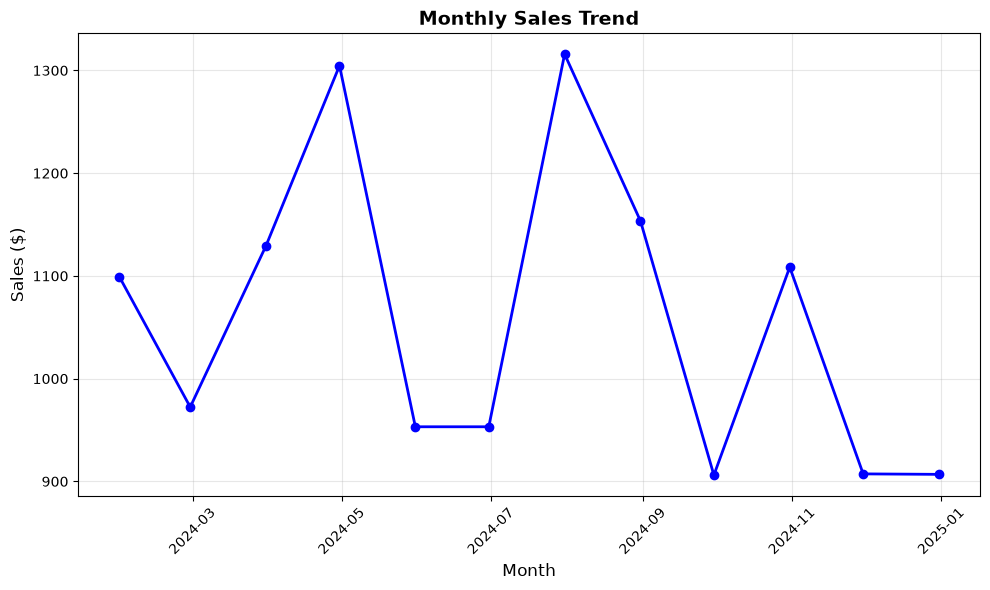

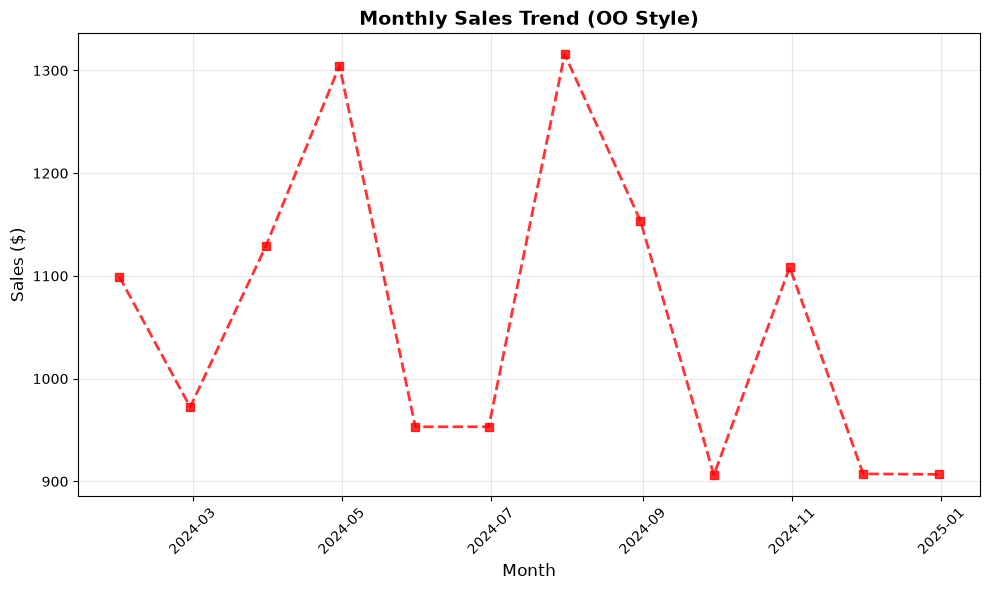

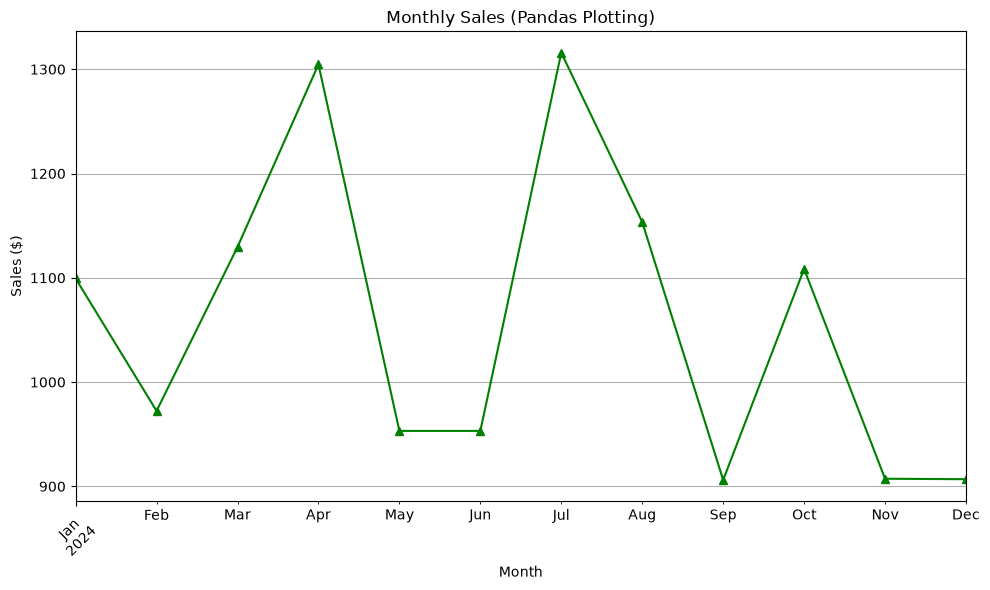

In [22]:
# --- Matplotlib fundamentals ---

# Simple pyplot approach
plt.figure(figsize=(10, 6))
plt.plot(sales_data['Month'], sales_data['Sales'], 'b-o', linewidth=2, markersize=6)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Object-oriented approach
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sales_data['Month'], sales_data['Sales'], 'r--s', linewidth=2, markersize=6, alpha=0.8)
ax.set_title('Monthly Sales Trend (OO Style)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Sales ($)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x',rotation=45)
plt.tight_layout()
plt.show()

# Pandas plotting
sales_data.set_index('Month')['Sales'].plot(
    figsize=(10, 6), 
    style='g-^', 
    title='Monthly Sales (Pandas Plotting)',
    ylabel='Sales ($)',
    grid=True
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 3. Common Plot Types with Matplotlib

Master these essential plot types that form the foundation of data visualization.

### Line Plots

| Use Case | Best For | Key Parameters |
|----------|----------|----------------|
| Time series | Trends over time | `marker`, `linestyle`, `color` |
| Comparisons | Multiple series | `label`, `legend()` |
| Trends | Smooth patterns | `linewidth`, `alpha` |

### Bar Charts

| Type | Use Case | Method |
|------|----------|--------|
| Vertical | Category comparison | `ax.bar()` |
| Horizontal | Long category names | `ax.barh()` |
| Stacked | Composition | `bottom` parameter |
| Grouped | Multiple categories | Multiple `ax.bar()` calls |

### Scatter Plots

| Feature | Purpose | Parameter |
|---------|---------|-----------|
| Size | Third variable | `s` parameter |
| Color | Fourth variable | `c` parameter |
| Shape | Categories | `marker` parameter |
| Transparency | Overplotting | `alpha` parameter |

> ⚠️ **Special Case — Color mapping**: Use `cmap` parameter for continuous color scales, not discrete colors.

> **Data Science relevance**: These plots are the workhorses of EDA — they reveal distributions, relationships, and outliers.

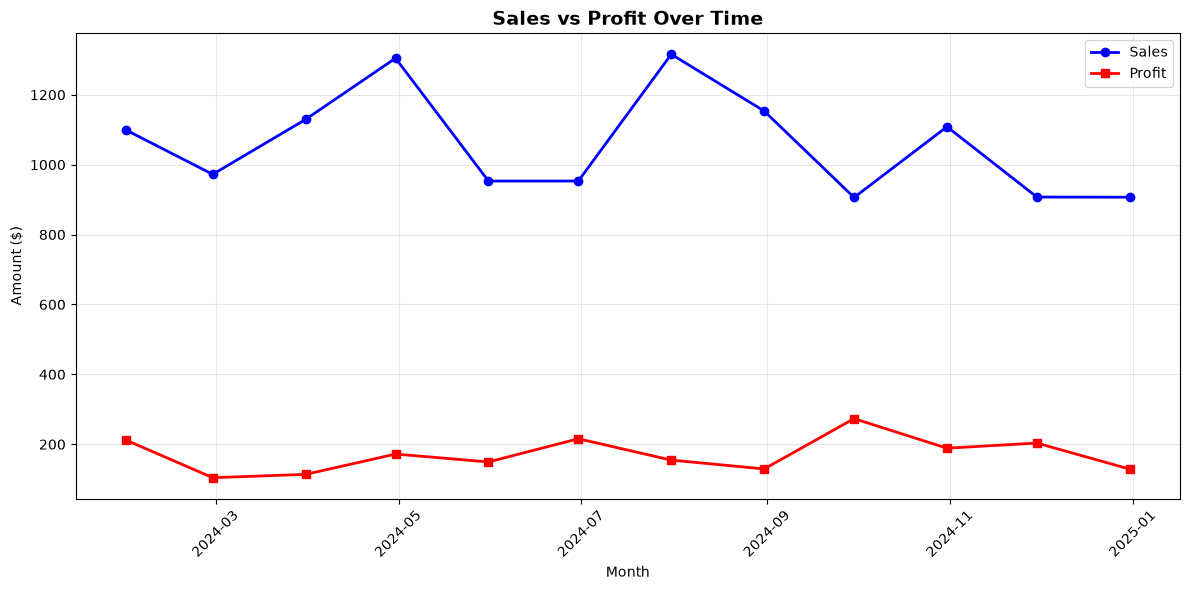

In [23]:
# --- Line plots ---
fig, ax = plt.subplots(figsize=(12, 6))

# Multiple lines on same plot
ax.plot(sales_data['Month'], sales_data['Sales'], 'b-o', label='Sales', linewidth=2)
ax.plot(sales_data['Month'], sales_data['Profit'], 'r-s', label='Profit', linewidth=2)

ax.set_title('Sales vs Profit Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Amount ($)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

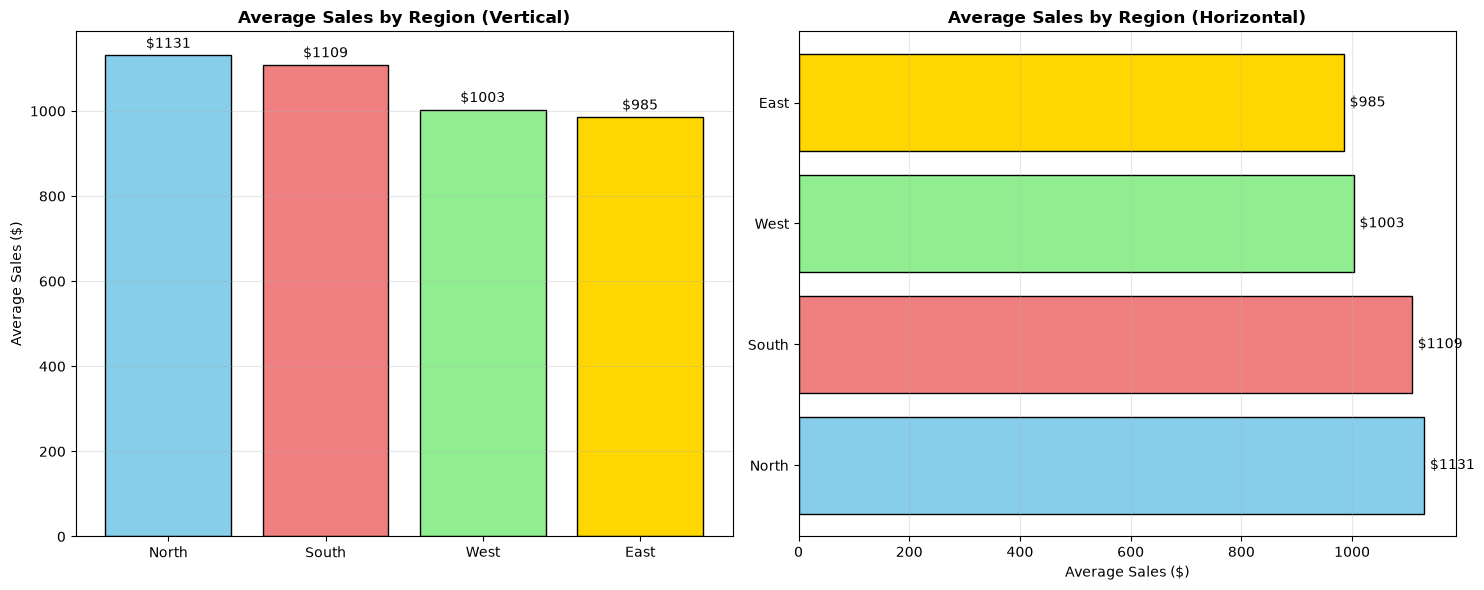

In [24]:
# --- Bar charts ---
region_sales = sales_data.groupby('Region')['Sales'].mean().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Vertical bar chart
bars1 = ax1.bar(region_sales.index, region_sales.values, 
                color=['skyblue', 'lightcoral', 'lightgreen', 'gold'],
                edgecolor='black', linewidth=1)
ax1.set_title('Average Sales by Region (Vertical)', fontweight='bold')
ax1.set_ylabel('Average Sales ($)')
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'${height:.0f}', ha='center', va='bottom')

# Horizontal bar chart
bars2 = ax2.barh(region_sales.index, region_sales.values,
                 color=['skyblue', 'lightcoral', 'lightgreen', 'gold'],
                 edgecolor='black', linewidth=1)
ax2.set_title('Average Sales by Region (Horizontal)', fontweight='bold')
ax2.set_xlabel('Average Sales ($)')
ax2.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for bar in bars2:
    width = bar.get_width()
    ax2.text(width + 10, bar.get_y() + bar.get_height()/2.,
             f'${width:.0f}', ha='left', va='center')

plt.tight_layout()
plt.show()

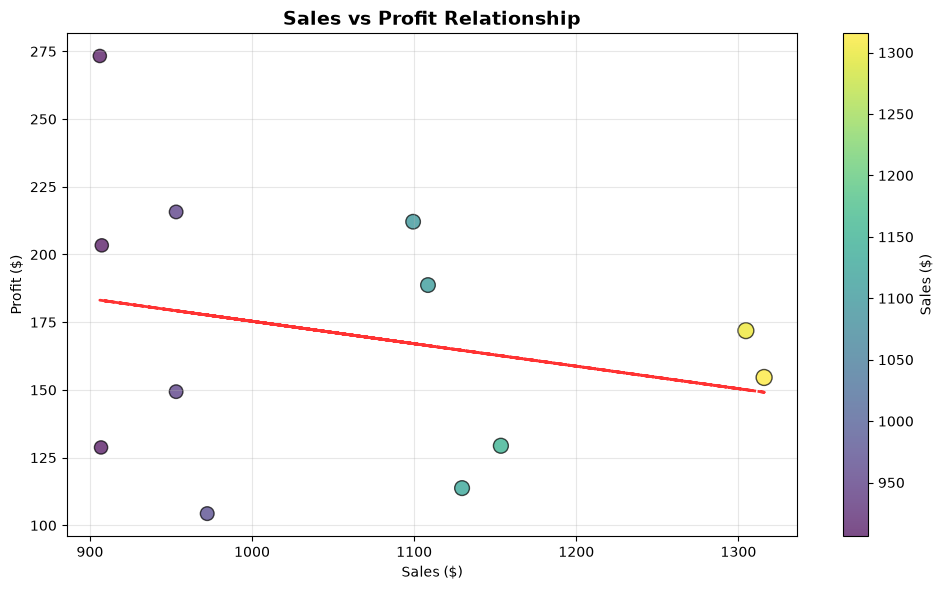

In [25]:
# --- Scatter plots ---
fig, ax = plt.subplots(figsize=(10, 6))

# Basic scatter plot
scatter = ax.scatter(sales_data['Sales'], sales_data['Profit'],
                     s=sales_data['Sales']/10,  # Size based on sales
                     c=sales_data['Sales'],     # Color based on sales
                     cmap='viridis', alpha=0.7, edgecolors='black')

ax.set_title('Sales vs Profit Relationship', fontsize=14, fontweight='bold')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Profit ($)')
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Sales ($)')

# Add trend line
z = np.polyfit(sales_data['Sales'], sales_data['Profit'], 1)
p = np.poly1d(z)
ax.plot(sales_data['Sales'], p(sales_data['Sales']), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

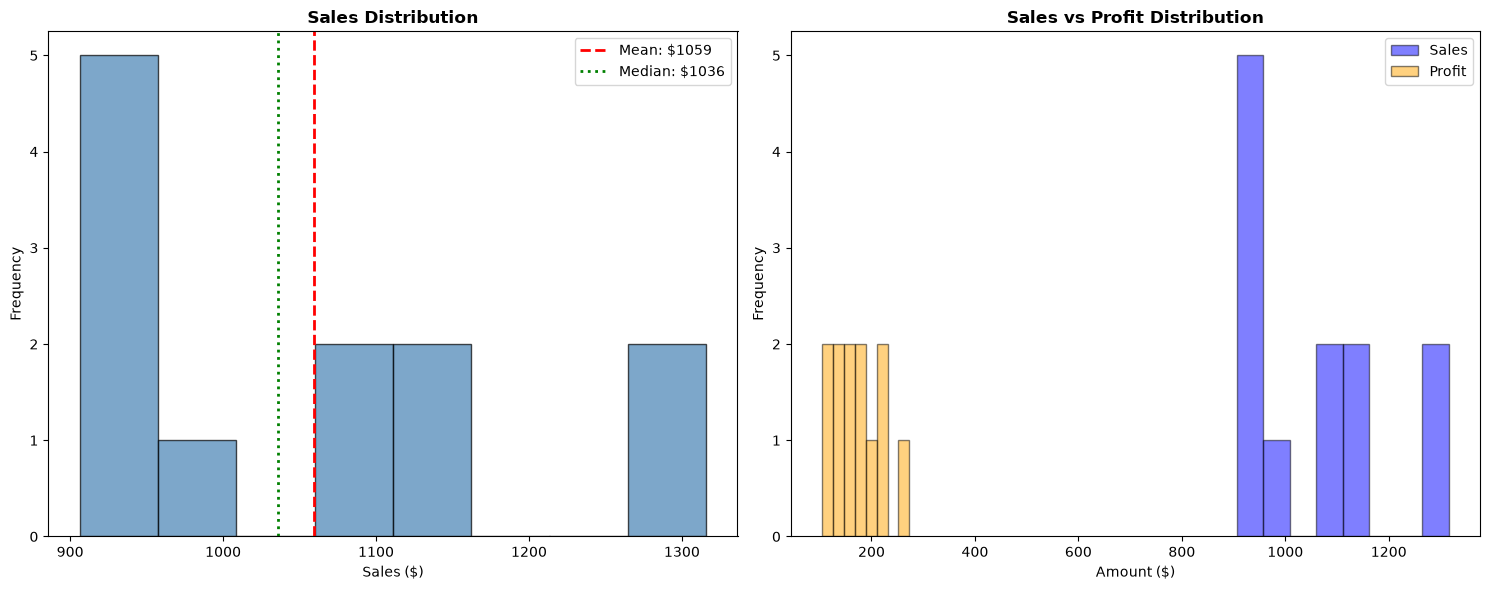

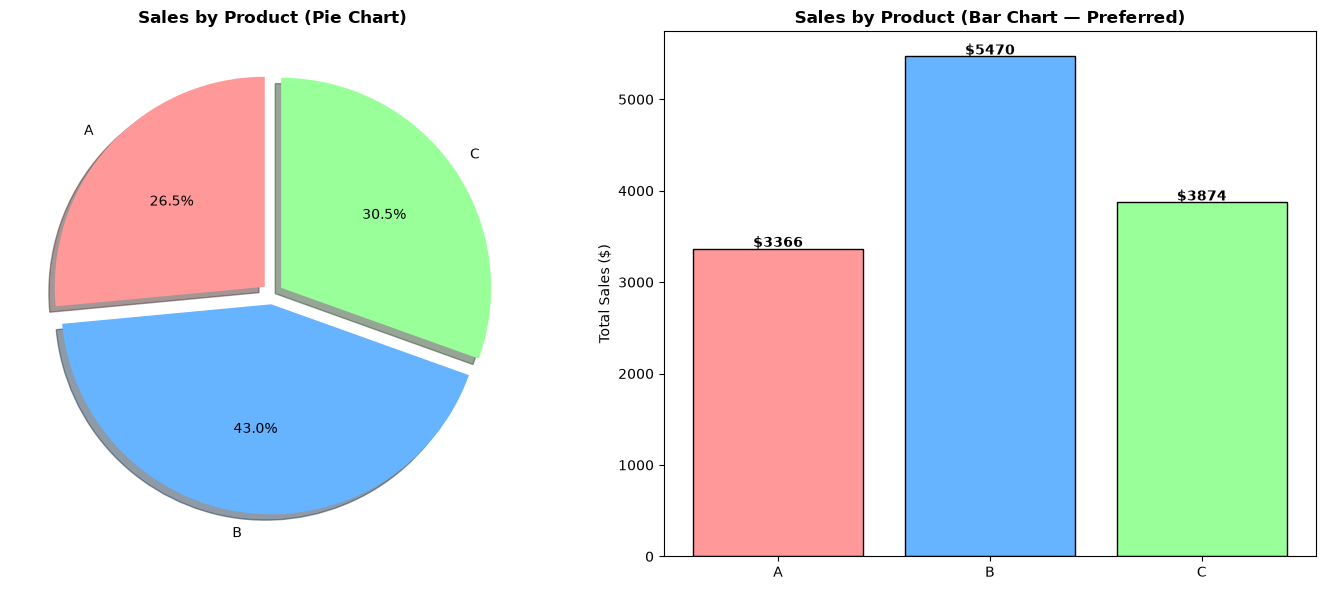

In [26]:
# --- Histograms ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Basic histogram
ax1.hist(sales_data['Sales'], bins=8, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(sales_data['Sales'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: ${sales_data["Sales"].mean():.0f}')
ax1.axvline(sales_data['Sales'].median(), color='green', linestyle=':', linewidth=2,
            label=f'Median: ${sales_data["Sales"].median():.0f}')
ax1.set_title('Sales Distribution', fontweight='bold')
ax1.set_xlabel('Sales ($)')
ax1.set_ylabel('Frequency')
ax1.legend()

# Overlapping histograms for comparison
ax2.hist(sales_data['Sales'], bins=8, alpha=0.5, label='Sales', color='blue', edgecolor='black')
ax2.hist(sales_data['Profit'], bins=8, alpha=0.5, label='Profit', color='orange', edgecolor='black')
ax2.set_title('Sales vs Profit Distribution', fontweight='bold')
ax2.set_xlabel('Amount ($)')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout()
plt.show()

# --- Pie chart (use sparingly — bar charts are usually better) ---
product_sales = sales_data.groupby('Product')['Sales'].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
ax1.pie(product_sales, labels=product_sales.index, autopct='%1.1f%%',
        startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'],
        explode=[0.05] * len(product_sales), shadow=True)
ax1.set_title('Sales by Product (Pie Chart)', fontweight='bold')

# Equivalent bar chart — almost always clearer
ax2.bar(product_sales.index, product_sales.values,
        color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black')
ax2.set_title('Sales by Product (Bar Chart — Preferred)', fontweight='bold')
ax2.set_ylabel('Total Sales ($)')
for i, v in enumerate(product_sales.values):
    ax2.text(i, v + 20, f'${v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 4. Advanced Matplotlib (Subplots & Customization)

Complex visualizations require multiple plots and fine-tuned appearance.

### Subplot Arrangements

| Method | Use Case | Syntax |
|--------|----------|--------|
| `plt.subplot()` | Simple grids | `plt.subplot(2, 2, 1)` |
| `plt.subplots()` | Complex layouts | `fig, axes = plt.subplots(2, 2)` |
| `plt.subplot2grid()` | Irregular grids | `plt.subplot2grid((3,3), (0,0), colspan=2)` |
| `gridspec` | Advanced layouts | `gs = fig.add_gridspec(3, 3)` |

### Customization Techniques

| Element | Method | Options |
|---------|--------|---------|
| Colors | `color`, `cmap` | Named colors, hex, RGB, colormaps |
| Line styles | `linestyle` | `'-'`, `'--'`, `'-.'`, `':'` |
| Markers | `marker` | `'o'`, `'s'`, `'^'`, `'*'`, etc. |
| Text | `fontsize`, `fontweight` | Size, weight, family |
| Spines | `ax.spines` | Hide/show axis borders |

### Advanced Features

| Feature | Purpose | Method |
|---------|---------|--------|
| Annotations | Highlight points | `ax.annotate()` |
| Secondary axis | Dual scales | `ax.twinx()`, `ax.twiny()` |
| Error bars | Show uncertainty | `ax.errorbar()` |
| Fill areas | Highlight regions | `ax.fill_between()` |
| Custom legends | Complex legends | `ax.legend()` with handles |

> ⚠️ **Special Case — tight_layout()**: Always call this before `plt.show()` to prevent overlapping elements.

> **Data Science relevance**: Publication-quality plots require attention to detail. Subplots help compare multiple views of the same data.

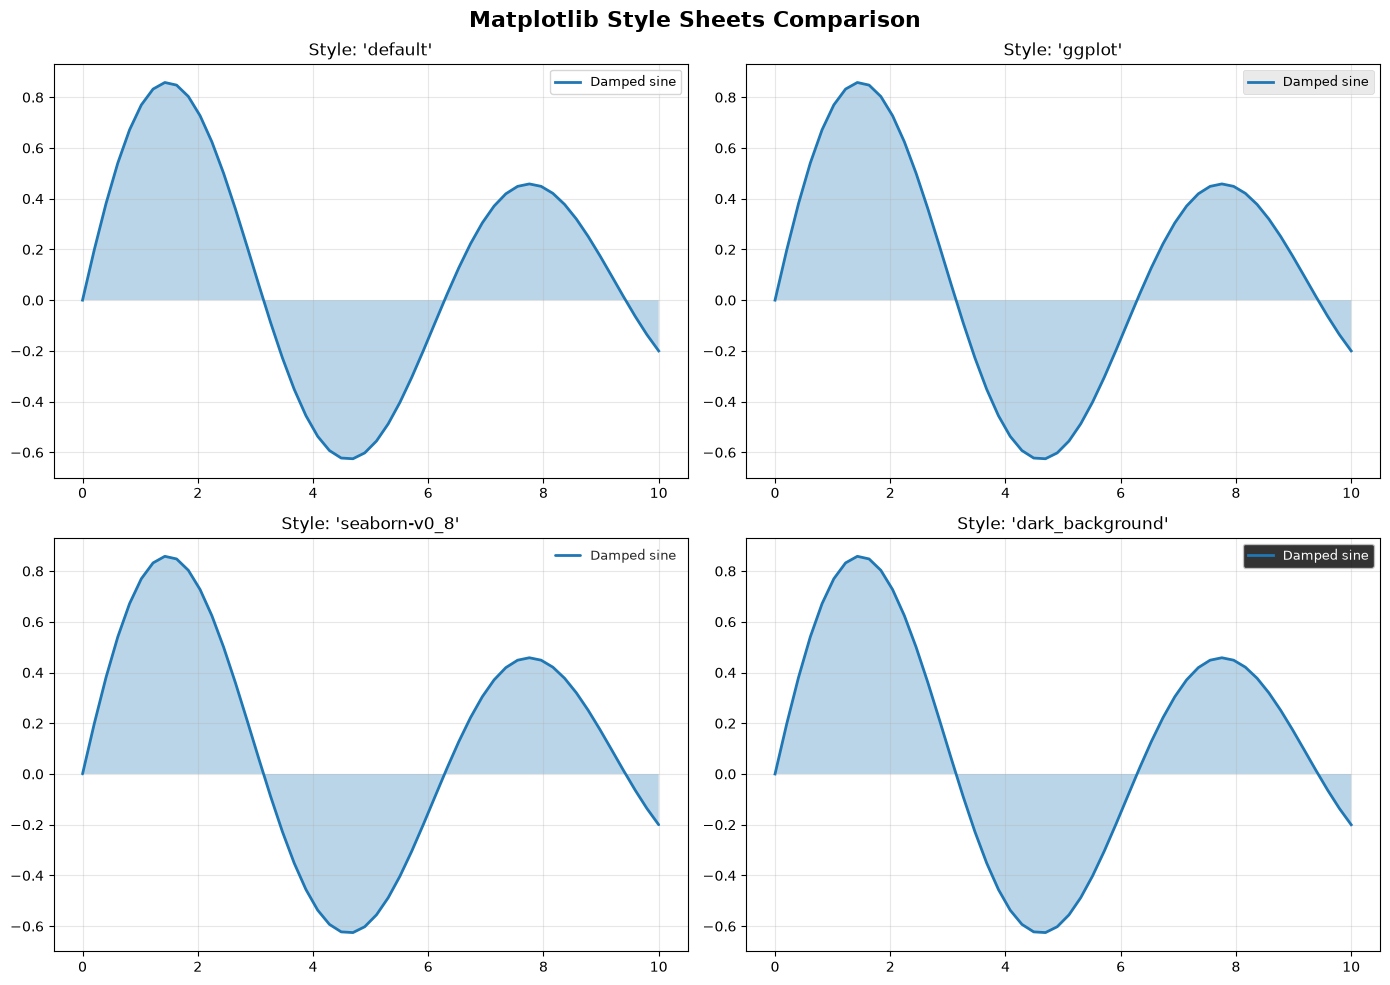

All available styles:
['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [27]:
# --- Style sheets comparison ---
styles = ['default', 'ggplot', 'seaborn-v0_8', 'dark_background']
x_demo = np.linspace(0, 10, 50)
y_demo = np.sin(x_demo) * np.exp(-x_demo / 10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Matplotlib Style Sheets Comparison', fontsize=16, fontweight='bold')

for ax, style_name in zip(axes.flat, styles):
    with plt.style.context(style_name):
        ax.plot(x_demo, y_demo, linewidth=2, label='Damped sine')
        ax.fill_between(x_demo, y_demo, alpha=0.3)
        ax.set_title(f"Style: '{style_name}'", fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("All available styles:")
print(plt.style.available)

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

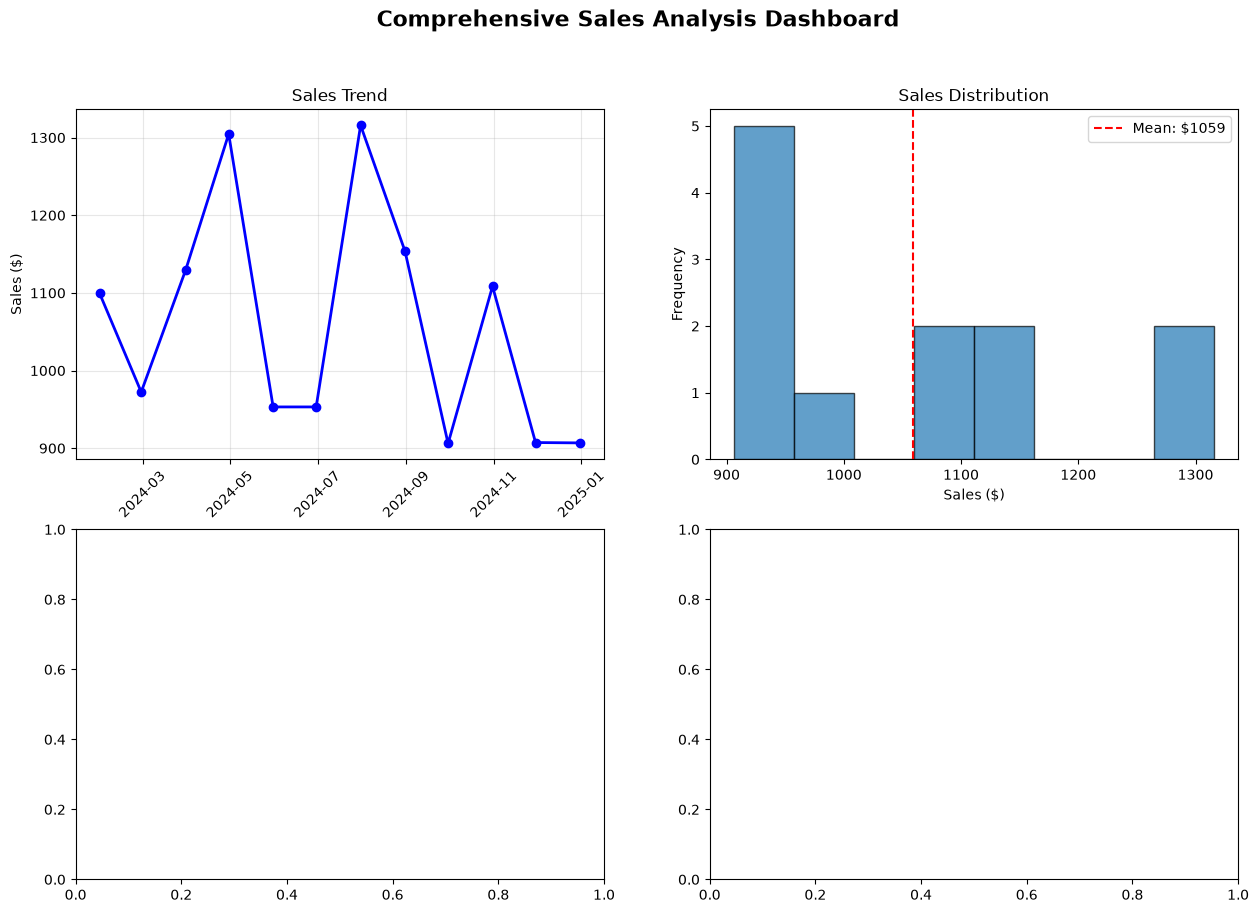

In [28]:
# --- Advanced subplots ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comprehensive Sales Analysis Dashboard', fontsize=16, fontweight='bold')

# Top-left: Time series
axes[0, 0].plot(sales_data['Month'], sales_data['Sales'], 'b-o', linewidth=2)
axes[0, 0].set_title('Sales Trend')
axes[0, 0].set_ylabel('Sales ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Top-right: Distribution
axes[0, 1].hist(sales_data['Sales'], bins=8, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Sales Distribution')
axes[0, 1].set_xlabel('Sales ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(sales_data['Sales'].mean(), color='red', linestyle='--', label=f'Mean: ${sales_data["Sales"].mean():.0f}')
axes[0, 1].legend()

# Bottom-left: Box plot by region
region_data = [sales_data[sales_data['Region'] == region]['Sales'] for region in sales_data['Region'].unique()]
axes[1, 0].boxplot(region_data, labels=sales_data['Region'].unique())
axes[1, 0].set_title('Sales by Region')
axes[1, 0].set_ylabel('Sales ($)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Bottom-right: Scatter with regions
colors = {'North': 'blue', 'South': 'red', 'East': 'green', 'West': 'orange'}
for region in sales_data['Region'].unique():
    subset = sales_data[sales_data['Region'] == region]
    axes[1, 1].scatter(subset['Sales'], subset['Profit'], 
                       label=region, color=colors[region], alpha=0.7, s=50)
axes[1, 1].set_title('Sales vs Profit by Region')
axes[1, 1].set_xlabel('Sales ($)')
axes[1, 1].set_ylabel('Profit ($)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

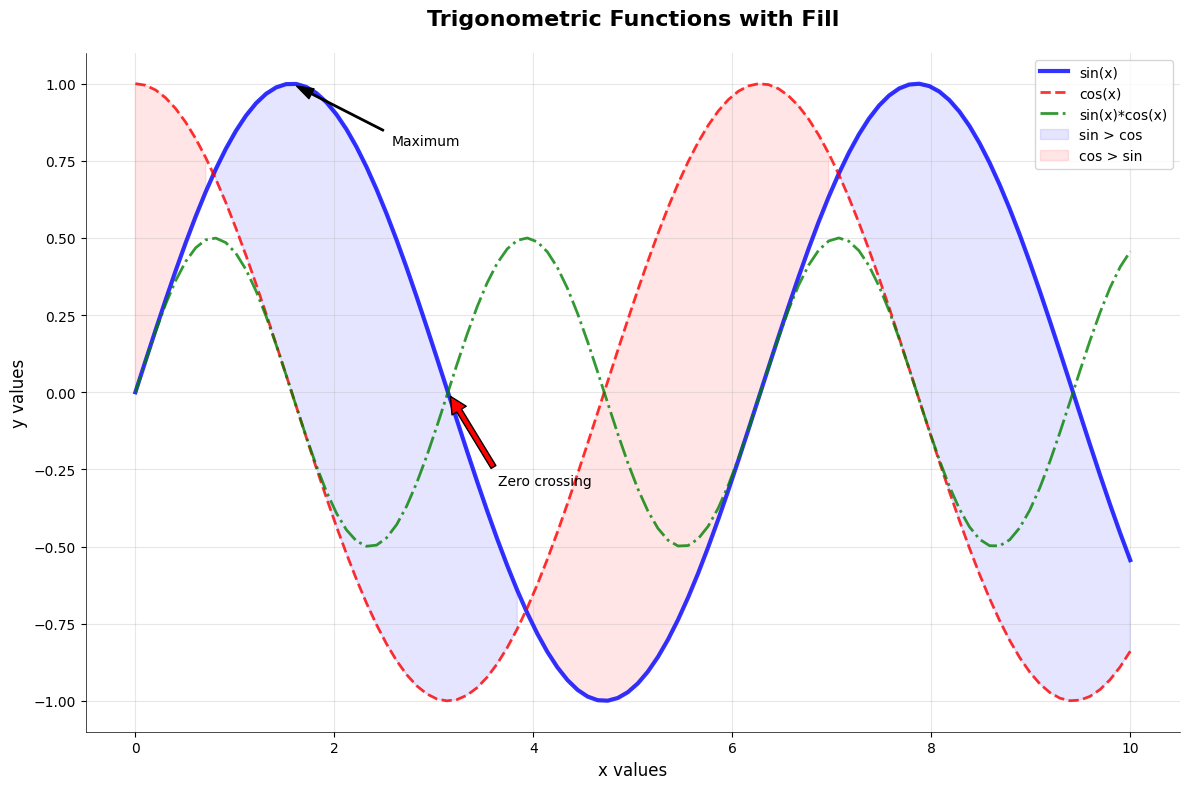

In [ ]:
# --- Advanced customization ---
fig, ax = plt.subplots(figsize=(12, 8))

# Create sophisticated plot
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x) * np.cos(x)

# Plot multiple lines with different styles
ax.plot(x, y1, 'b-', linewidth=3, label='sin(x)', alpha=0.8)
ax.plot(x, y2, 'r--', linewidth=2, label='cos(x)', alpha=0.8)
ax.plot(x, y3, 'g-.', linewidth=2, label='sin(x)*cos(x)', alpha=0.8)

# Fill between curves
ax.fill_between(x, y1, y2, where=(y1 > y2), color='blue', alpha=0.1, label='sin > cos')
ax.fill_between(x, y1, y2, where=(y1 < y2), color='red', alpha=0.1, label='cos > sin')

# Customize appearance
ax.set_title('Trigonometric Functions with Fill', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('x values', fontsize=12)
ax.set_ylabel('y values', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Customize spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# Add annotations
ax.annotate('Maximum', xy=(np.pi/2, 1), xytext=(np.pi/2 + 1, 0.8),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

ax.annotate('Zero crossing', xy=(np.pi, 0), xytext=(np.pi + 0.5, -0.3),
            arrowprops=dict(facecolor='red', shrink=0.05))

plt.tight_layout()
plt.show()

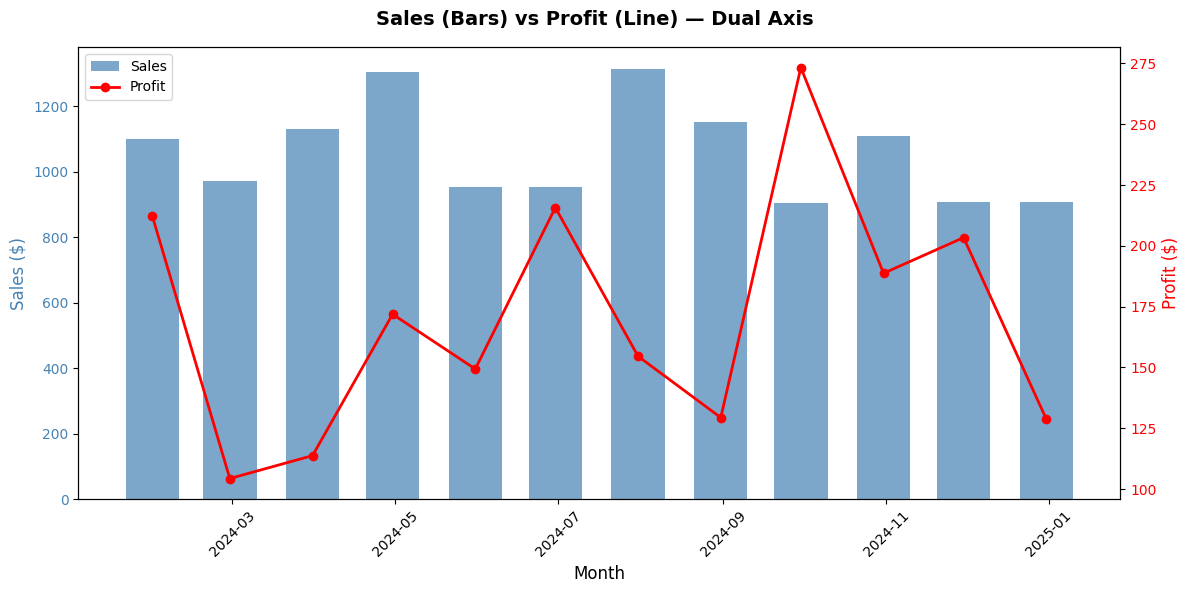

In [ ]:
# --- Dual-axis plot with twinx ---
fig, ax1 = plt.subplots(figsize=(12, 6))

months = sales_data['Month']
ax1.bar(months, sales_data['Sales'], color='steelblue', alpha=0.7, width=20, label='Sales')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Sales ($)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation=45)

# Secondary y-axis shares the same x-axis
ax2 = ax1.twinx()
ax2.plot(months, sales_data['Profit'], 'r-o', linewidth=2, markersize=6, label='Profit')
ax2.set_ylabel('Profit ($)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combined legend from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.suptitle('Sales (Bars) vs Profit (Line) — Dual Axis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\VaishnavVijayan\AppData\Local\Temp\ipykernel_27392\2753720640.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


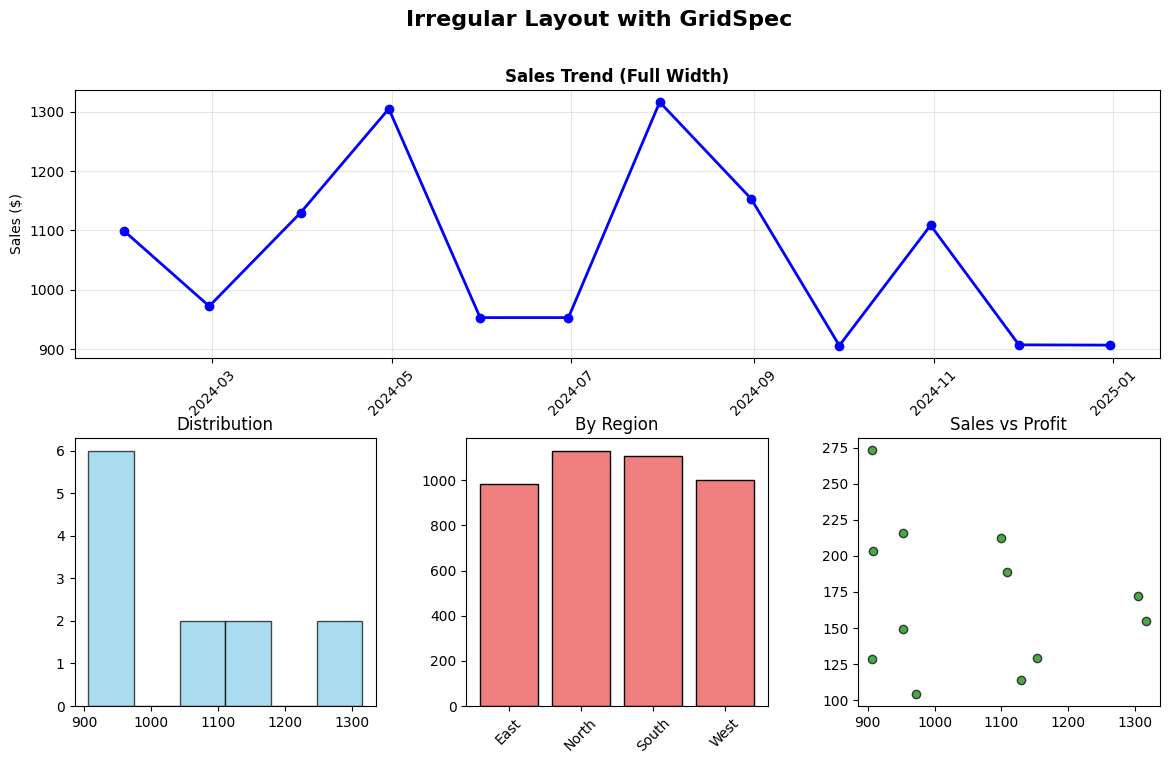

In [ ]:
# --- GridSpec for irregular subplot layouts ---
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Wide plot spanning top row
ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(sales_data['Month'], sales_data['Sales'], 'b-o', linewidth=2)
ax_top.set_title('Sales Trend (Full Width)', fontweight='bold')
ax_top.set_ylabel('Sales ($)')
ax_top.tick_params(axis='x', rotation=45)
ax_top.grid(True, alpha=0.3)

# Three smaller plots on bottom row
ax_bl = fig.add_subplot(gs[1, 0])
ax_bl.hist(sales_data['Sales'], bins=6, edgecolor='black', color='skyblue', alpha=0.7)
ax_bl.set_title('Distribution')

ax_bm = fig.add_subplot(gs[1, 1])
region_avg = sales_data.groupby('Region')['Sales'].mean()
ax_bm.bar(region_avg.index, region_avg.values, color='lightcoral', edgecolor='black')
ax_bm.set_title('By Region')
ax_bm.tick_params(axis='x', rotation=45)

ax_br = fig.add_subplot(gs[1, 2])
ax_br.scatter(sales_data['Sales'], sales_data['Profit'], c='green', alpha=0.7, edgecolors='black')
ax_br.set_title('Sales vs Profit')

fig.suptitle('Irregular Layout with GridSpec', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

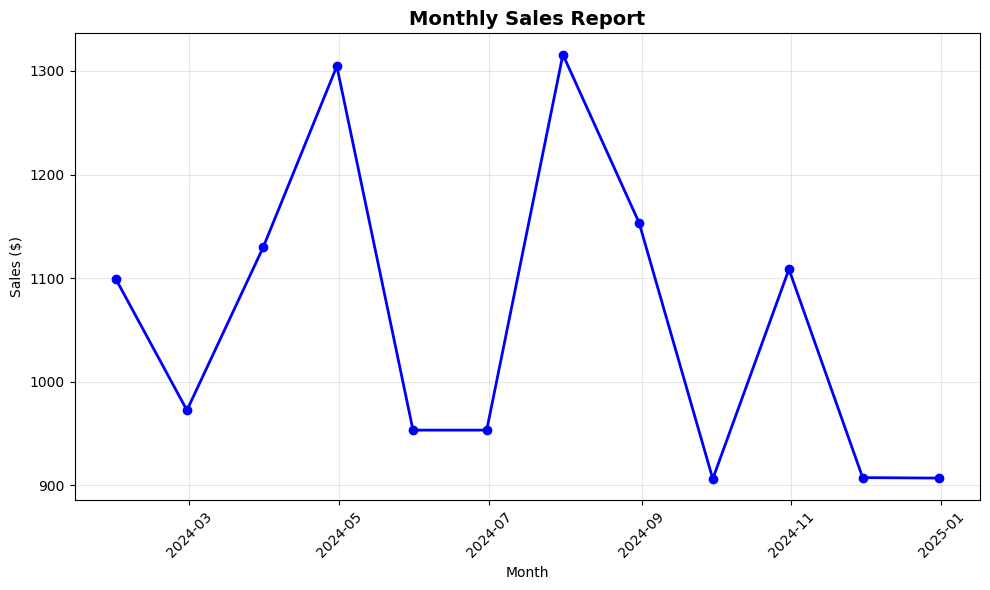

Figures saved as:
  sales_report.png  — High-res raster (presentations, web)
  sales_report.pdf  — Vector format (publications, print)
  sales_report.svg  — Scalable vector (web, editing)

Key parameters:
  dpi=300         — Dots per inch (150=screen, 300=print, 600=publication)
  bbox_inches='tight' — Removes extra whitespace around the plot


In [ ]:
# --- Saving figures ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sales_data['Month'], sales_data['Sales'], 'b-o', linewidth=2)
ax.set_title('Monthly Sales Report', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($)')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

# Save in different formats
fig.savefig('sales_report.png', dpi=300, bbox_inches='tight')
fig.savefig('sales_report.pdf', bbox_inches='tight')
fig.savefig('sales_report.svg', bbox_inches='tight')
plt.show()

print("Figures saved as:")
print("  sales_report.png  — High-res raster (presentations, web)")
print("  sales_report.pdf  — Vector format (publications, print)")
print("  sales_report.svg  — Scalable vector (web, editing)")
print(f"\nKey parameters:")
print(f"  dpi=300         — Dots per inch (150=screen, 300=print, 600=publication)")
print(f"  bbox_inches='tight' — Removes extra whitespace around the plot")

---
## 5. Introduction to Seaborn

Seaborn builds on Matplotlib to create beautiful statistical visualizations with less code.

### Seaborn vs Matplotlib

| Aspect | Matplotlib | Seaborn |
|--------|------------|---------|
| **Philosophy** | Full control | Beautiful defaults |
| **Code length** | Verbose | Concise |
| **Statistical plots** | Manual | Built-in |
| **Themes** | Basic | Sophisticated |
| **Data handling** | Manual | DataFrame-native |

### Key Seaborn Functions

| Function | Purpose | Best For |
|----------|---------|----------|
| `sns.lineplot()` | Time series, trends | Sequential data |
| `sns.barplot()` | Category comparison | Means with confidence intervals |
| `sns.scatterplot()` | Relationships | Two continuous variables |
| `sns.histplot()` | Distributions | Single variable distribution |
| `sns.boxplot()` | Distribution comparison | Categories vs continuous |
| `sns.heatmap()` | Correlation matrix | Variable relationships |

### Seaborn Themes

| Theme | Description | Use Case |
|-------|-------------|----------|
| `sns.set_style('darkgrid')` | Dark background with grid | Presentations |
| `sns.set_style('whitegrid')` | White background with grid | Reports |
| `sns.set_style('dark')` | Dark background | Clean look |
| `sns.set_style('white')` | White background | Minimal |
| `sns.set_style('ticks')` | Tick marks only | Publications |

> ⚠️ **Special Case — Seaborn integration**: Seaborn works with Matplotlib figures. You can use both libraries together.

> **Data Science relevance**: Seaborn makes statistical visualization fast and beautiful, perfect for exploratory data analysis.

Seaborn 'tips' dataset:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Shape: (244, 7)


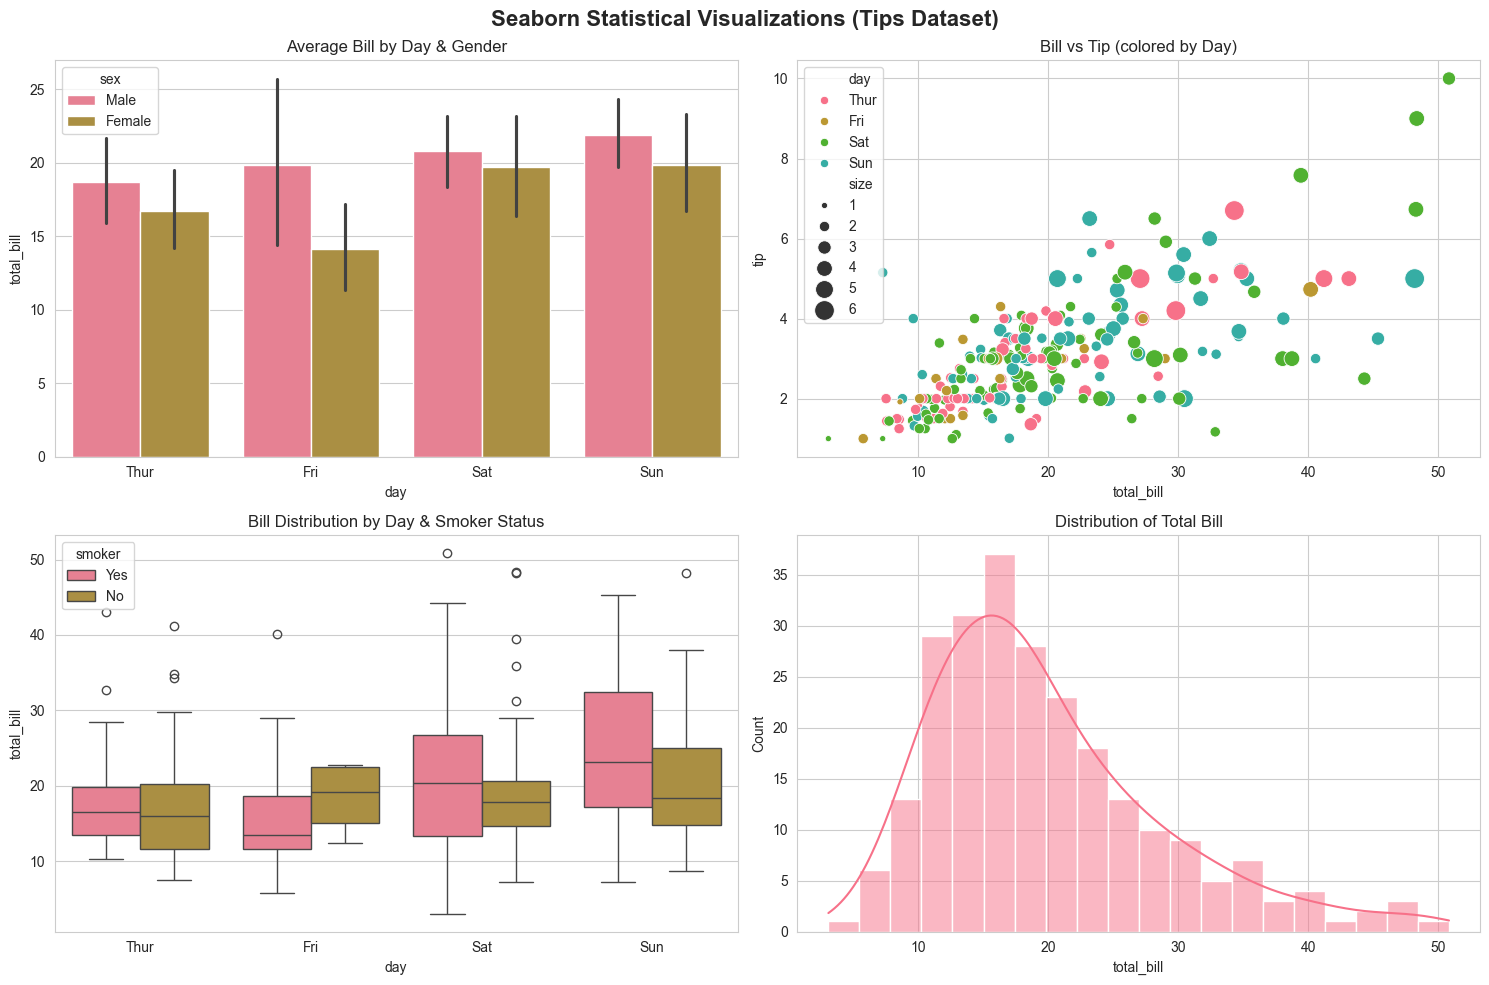

In [ ]:
# --- Seaborn basics with built-in dataset ---

# Seaborn ships with real datasets — great for learning
tips = sns.load_dataset('tips')
print("Seaborn 'tips' dataset:")
print(tips.head())
print(f"\nShape: {tips.shape}")

# Set seaborn style
sns.set_style('whitegrid')
sns.set_palette('husl')

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Seaborn Statistical Visualizations (Tips Dataset)', fontsize=16, fontweight='bold')

# Bar plot with confidence intervals (automatic)
sns.barplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[0, 0])
axes[0, 0].set_title('Average Bill by Day & Gender')

# Scatter plot with hue and size
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='day', size='size',
                sizes=(20, 200), ax=axes[0, 1])
axes[0, 1].set_title('Bill vs Tip (colored by Day)')

# Box plot
sns.boxplot(data=tips, x='day', y='total_bill', hue='smoker', ax=axes[1, 0])
axes[1, 0].set_title('Bill Distribution by Day & Smoker Status')

# Histogram with KDE overlay
sns.histplot(data=tips, x='total_bill', kde=True, bins=20, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Total Bill')

plt.tight_layout()
plt.show()

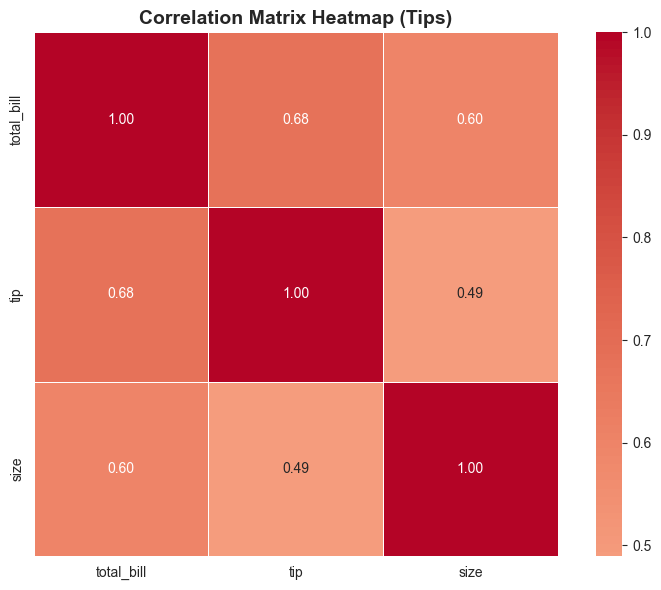

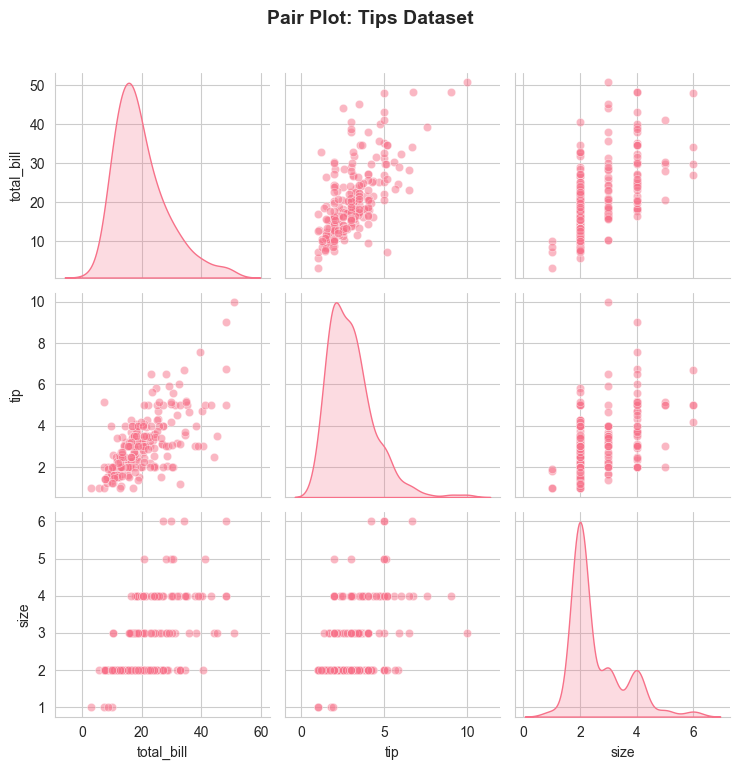

In [ ]:
# --- Seaborn advanced features ---

# Correlation heatmap
numeric_tips = tips.select_dtypes(include='number')
correlation_matrix = numeric_tips.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix Heatmap (Tips)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Pair plot — creates its own figure (no plt.figure needed)
pair_plot = sns.pairplot(tips[['total_bill', 'tip', 'size']], diag_kind='kde',
                         plot_kws={'alpha': 0.5})
pair_plot.fig.suptitle('Pair Plot: Tips Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 🧪 Practice Exercises

**Matplotlib Basics**
1. Create a line plot showing both Sales and Profit trends over time using the OO interface. Add a legend, grid, and descriptive title.
2. Build a horizontal bar chart comparing average sales by product with value labels on each bar.
3. Create a histogram of Profit values with 10 bins, overlaying a vertical line for the mean and median.

**Advanced Matplotlib**
4. Design a 2x2 subplot dashboard showing: (a) sales histogram, (b) box plot by product, (c) line plot of profit, (d) scatter plot with regions.
5. Create a dual-axis plot (`twinx`) showing Sales as bars and Profit as a line on the same figure.
6. Use `GridSpec` to create an irregular layout: one wide plot on top (spanning 3 columns) and two smaller plots on the bottom.
7. Create a publication-ready figure and save it as both PNG (300 DPI) and PDF.

**Seaborn & Data Selection**
8. Load Seaborn's `iris` dataset and create a scatter plot of `sepal_length` vs `petal_length`, colored by `species`.
9. Use the `tips` dataset to create a box plot of `total_bill` grouped by `day`, with `hue='smoker'`.
10. Given a dataset, which plot type would you choose and why? (a) Comparing revenue across 4 regions, (b) Showing how temperature changes over a year, (c) Examining the relationship between study hours and exam score, (d) Showing the distribution of house prices.

---
## 📝 Session 11 Summary

| Topic | Key Takeaway |
|-------|---------------|
| **Matplotlib fundamentals** | Figure, axes, artists — understand the architecture for control |
| **Plot types** | Line, bar, scatter, histogram, pie — choose based on data relationships |
| **Subplots & customization** | Subplots, GridSpec, twinx, annotations, style sheets |
| **Saving figures** | `savefig()` with DPI and format control for publication-quality output |
| **Seaborn introduction** | Statistical plots with beautiful defaults and less code |
| **Integration** | Matplotlib + Seaborn + pandas for comprehensive visualization |

### Key Takeaways
- **Matplotlib** gives you complete control over every visual element
- **Choose plot types** based on your data types and relationships
- **Subplots** enable dashboard-style analysis of multiple variables
- **Customization** (colors, styles, annotations) makes plots professional
- **Save figures** with `savefig()` — use `dpi=300` and `bbox_inches='tight'` for clean output
- **Seaborn** accelerates statistical visualization with smart defaults and built-in datasets

### Key Gotchas to Remember
- `plt.show()` **clears the figure** — save before showing, or use the OO interface
- Always call `plt.tight_layout()` or `bbox_inches='tight'` to prevent overlapping labels
- `sns.pairplot()` and `sns.catplot()` create their own figures — don't wrap them in `plt.figure()`
- Use **colorblind-friendly palettes** (`viridis`, `cividis`) for accessibility
- Pie charts are almost always worse than bar charts — use sparingly
- `ax.twinx()` can confuse readers — always use clear color coding and a combined legend

### Next Session
**Session 12**: Advanced Seaborn and Statistical Visualization — deep dive into Seaborn's statistical plotting capabilities.